## Linear Regression
This file is about using linear regression to train a model to predict rating 3.0 of a player.

In [1]:
import pandas as pd
df = pd.read_excel('preprocessed_data.xlsx')
display(df.head())

,Player,Rating 3.0,Kills per round,Kills per round win,Damage per round,Damage per round win,Rounds with a kill,Rounds with a multi-kill,Saved by teammate per round,Traded deaths per round,...,Sniper kills per round,Sniper kills percentage,Rounds with sniper kills percentage,Sniper multi-kill rounds,Sniper opening kills per round,Utility damage per round,Utility kills per 100 rounds,Flashes thrown per round,Flash assists per round,Time opponent flashed per round
0,donk,1.38,4.496020,4.144459,4.251909,3.834787,3.644449,4.552464,0.326134,0.709361,...,-0.482528,-0.487194,-0.477251,-0.422801,-0.436333,-0.847340,-1.479030,-0.870158,-1.603766,-1.789788
1,ZywOo,1.34,3.200176,2.206957,2.583746,1.931851,2.896591,3.308668,-0.370746,-0.815990,...,1.768442,1.334941,1.675290,1.977071,1.850832,-0.301064,0.655636,0.158405,0.503270,0.218072
2,m0NESY,1.26,2.459693,1.948623,1.471637,1.214992,2.373089,2.479470,-1.067627,-0.815990,...,2.411577,2.013997,2.249998,2.608616,2.533568,-1.019848,-0.589586,0.642434,1.346084,0.173453
3,Luken,1.24,2.459693,2.206957,2.257783,1.840615,2.036553,2.427645,0.326134,-0.307540,...,-0.482528,-0.509830,-0.508598,-0.517532,-0.470470,-0.552638,-0.091497,-0.567640,-0.760952,-0.361976
4,Frip,1.23,2.274573,2.723624,3.101452,3.157029,2.036553,2.583120,1.023014,0.709361,...,-0.241353,-0.317430,-0.268266,-0.359646,-0.197375,-0.157307,-0.340541,-0.809654,-0.760952,-0.406595


### 1. Data Preparation and Splitting

First, I'll define the features (`X`) and the target variable (`y`). Then, I'll split the data into training, validation, and test sets using `train_test_split` from `sklearn.model_selection`.

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Define target variable (y) and features (X)
y = df['Rating 3.0']
X = df.drop(columns=['Player', 'Rating 3.0'])

# Display target variable (y) and features (X)
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
display(X.head())
display(y.head())

Features (X) shape: (453, 37)
Target (y) shape: (453,)


,Kills per round,Kills per round win,Damage per round,Damage per round win,Rounds with a kill,Rounds with a multi-kill,Saved by teammate per round,Traded deaths per round,Opening deaths traded percentage,Assits per round,...,Sniper kills per round,Sniper kills percentage,Rounds with sniper kills percentage,Sniper multi-kill rounds,Sniper opening kills per round,Utility damage per round,Utility kills per 100 rounds,Flashes thrown per round,Flash assists per round,Time opponent flashed per round
0,4.496020,4.144459,4.251909,3.834787,3.644449,4.552464,0.326134,0.709361,-0.220940,0.584043,...,-0.482528,-0.487194,-0.477251,-0.422801,-0.436333,-0.847340,-1.479030,-0.870158,-1.603766,-1.789788
1,3.200176,2.206957,2.583746,1.931851,2.896591,3.308668,-0.370746,-0.815990,-0.498507,-0.346455,...,1.768442,1.334941,1.675290,1.977071,1.850832,-0.301064,0.655636,0.158405,0.503270,0.218072
2,2.459693,1.948623,1.471637,1.214992,2.373089,2.479470,-1.067627,-0.815990,0.241671,-1.587118,...,2.411577,2.013997,2.249998,2.608616,2.533568,-1.019848,-0.589586,0.642434,1.346084,0.173453
3,2.459693,2.206957,2.257783,1.840615,2.036553,2.427645,0.326134,-0.307540,-0.637290,0.894209,...,-0.482528,-0.509830,-0.508598,-0.517532,-0.470470,-0.552638,-0.091497,-0.567640,-0.760952,-0.361976
4,2.274573,2.723624,3.101452,3.157029,2.036553,2.583120,1.023014,0.709361,-0.683551,1.824707,...,-0.241353,-0.317430,-0.268266,-0.359646,-0.197375,-0.157307,-0.340541,-0.809654,-0.760952,-0.406595


,Rating 3.0
0,1.38
1,1.34
2,1.26
3,1.24
4,1.23


In [3]:
# Split data into training (70%), validation (15%), and test (15%) sets

# First split: 85% for train+validation, 15% for test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Second split: From the train+validation set, take 15/(100-15) for validation and the rest for training
# This makes the validation set approximately 15% of the total dataset
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=(0.15 / 0.85), random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 317 samples
Validation set size: 68 samples
Test set size: 68 samples


### 2. Linear Regression

Now, let's implement a Linear Regression model.

In [4]:
# Helper function to calculate MSE
def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# Helper function to calculate MAE
def calculate_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# Helper function to calculate R2 Score
def calculate_r2_score(y_true, y_pred):
    ss_total = np.sum((y_true - np.mean(y_true))**2)
    ss_res = np.sum((y_true - y_pred)**2)
    return 1 - (ss_res / ss_total)

#### 2.1 Scikit-learn Linear Regression

Now, let's implement a Linear Regression model using `sklearn.linear_model.LinearRegression` for comparison.

In [5]:
# Initialize and fit the Scikit-learn Linear Regression model
sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)

LinearRegression()

#### 2.2 Feature Weights after Training

In [6]:
feature_names = X.columns.tolist()
weights_df = pd.DataFrame({
    'Feature': ['Bias'] + feature_names,
    'Weight': np.concatenate([np.array([sklearn_model.intercept_]), sklearn_model.coef_]).flatten()
})

# Extract feature names and weights
feature_labels = weights_df['Feature'].tolist()
weight_values = weights_df['Weight'].round(4).tolist()

# Format as comma-separated strings
feature_line = ', '.join(feature_labels)
weight_line = ', '.join(map(str, weight_values))

# Print the desired output
print(feature_line)
print(weight_line)

Bias, Kills per round, Kills per round win, Damage per round, Damage per round win, Rounds with a kill, Rounds with a multi-kill, Saved by teammate per round, Traded deaths per round, Opening deaths traded percentage, Assits per round, Support rounds, Saved teammate per round, Trade kills per round, Trade kills percentage, Assisted kills percentage, Damage per kill, Opening kills per round, Opening deaths per round, Opening attempts, Opening success, Win% after openin kill, Attacks per round, Clutch points per round, Last alive percentage, 1 on 1 win percentage, Time alive per round, Saves per round loss, Sniper kills per round, Sniper kills percentage, Rounds with sniper kills percentage, Sniper multi-kill rounds, Sniper opening kills per round, Utility damage per round, Utility kills per 100 rounds, Flashes thrown per round, Flash assists per round, Time opponent flashed per round
1.0511, 0.0408, 0.006, 0.0391, -0.0132, 0.0106, 0.0014, 0.0015, 0.0114, -0.0004, -0.0122, 0.0266, 0.0047

#### 2.3 Visualizing Performance Metrics

In [7]:
# Make predictions
y_train_pred_sklearn = sklearn_model.predict(X_train).reshape(-1, 1)
y_val_pred_sklearn = sklearn_model.predict(X_val).reshape(-1, 1)
y_test_pred_sklearn = sklearn_model.predict(X_test).reshape(-1, 1)

# Convert y_true Series to numpy arrays for calculations
y_train_np = y_train.values.reshape(-1, 1)
y_val_np = y_val.values.reshape(-1, 1)
y_test_np = y_test.values.reshape(-1, 1)

# Calculate metrics for each set
mae_train_sklearn = calculate_mae(y_train_np, y_train_pred_sklearn)
mse_train_sklearn = calculate_mse(y_train_np, y_train_pred_sklearn)
rmse_train_sklearn = np.sqrt(mse_train_sklearn)
r2_train_sklearn = calculate_r2_score(y_train_np, y_train_pred_sklearn)

mae_val_sklearn = calculate_mae(y_val_np, y_val_pred_sklearn)
mse_val_sklearn = calculate_mse(y_val_np, y_val_pred_sklearn)
rmse_val_sklearn = np.sqrt(mse_val_sklearn)
r2_val_sklearn = calculate_r2_score(y_val_np, y_val_pred_sklearn)

mae_test_sklearn = calculate_mae(y_test_np, y_test_pred_sklearn)
mse_test_sklearn = calculate_mse(y_test_np, y_test_pred_sklearn)
rmse_test_sklearn = np.sqrt(mse_test_sklearn)
r2_test_sklearn = calculate_r2_score(y_test_np, y_test_pred_sklearn)

# Create a DataFrame to display results
performance_df_sklearn = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Training Set': [mae_train_sklearn, mse_train_sklearn, rmse_train_sklearn, r2_train_sklearn],
    'Validation Set': [mae_val_sklearn, mse_val_sklearn, rmse_val_sklearn, r2_val_sklearn],
    'Test Set': [mae_test_sklearn, mse_test_sklearn, rmse_test_sklearn, r2_test_sklearn]
})

print("Scikit-learn Linear Regression Performance:")
display(performance_df_sklearn)

Scikit-learn Linear Regression Performance:


,Metric,Training Set,Validation Set,Test Set
0,MAE,0.011566,0.013868,0.014731
1,MSE,0.000209,0.000327,0.000318
2,RMSE,0.014446,0.018095,0.017845
3,R2,0.954284,0.941843,0.954780


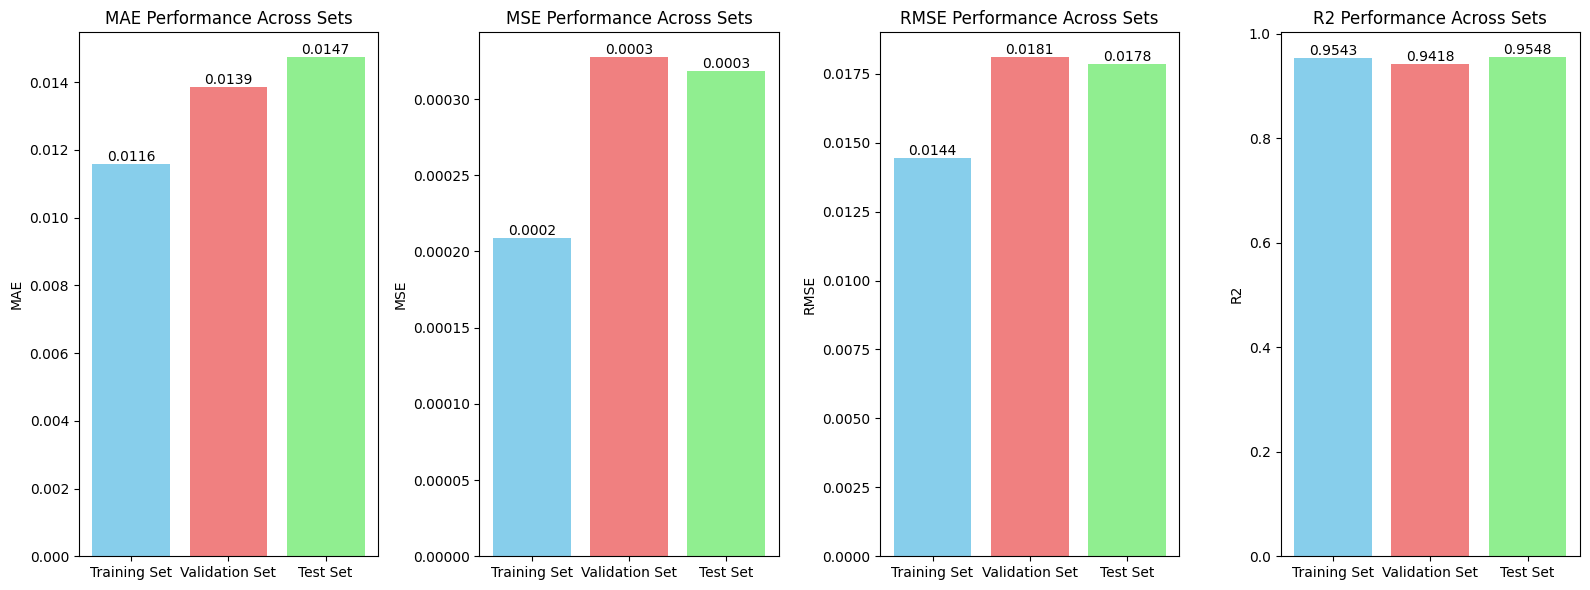

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 6))
axes = axes.flatten()

metrics = ['MAE', 'MSE', 'RMSE', 'R2']
colors = ['skyblue', 'lightcoral', 'lightgreen']

for i, metric in enumerate(metrics):
    metric_values = performance_df_sklearn[performance_df_sklearn['Metric'] == metric].iloc[0, 1:].values
    sets = ['Training Set', 'Validation Set', 'Test Set']

    axes[i].bar(sets, metric_values, color=colors)
    axes[i].set_title(f'{metric} Performance Across Sets')
    axes[i].set_ylabel(metric)
    for j, val in enumerate(metric_values):
        axes[i].text(j, val, f'{val:.4f}', ha='center', va='bottom')

    axes[i].autoscale(enable=True, axis='y', tight=False)

plt.tight_layout()
plt.show()